In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

properties_2016 = pd.read_csv('/kaggle/input/zillow-prize-1/properties_2016.csv')
train_2016 = pd.read_csv('/kaggle/input/zillow-prize-1/train_2016_v2.csv')

properties_2017 = pd.read_csv('/kaggle/input/zillow-prize-1/properties_2017.csv')
train_2017 = pd.read_csv('/kaggle/input/zillow-prize-1/train_2017.csv')

In [62]:
merged_2016 = pd.merge(train_2016, properties_2016, on='parcelid', how='left')
merged_2017 = pd.merge(train_2017, properties_2017, on='parcelid', how='left')

In [63]:
df= pd.concat([merged_2016, merged_2017], ignore_index=True)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167888 entries, 0 to 167887
Data columns (total 60 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   parcelid                      167888 non-null  int64  
 1   logerror                      167888 non-null  float64
 2   transactiondate               167888 non-null  object 
 3   airconditioningtypeid         53788 non-null   float64
 4   architecturalstyletypeid      468 non-null     float64
 5   basementsqft                  93 non-null      float64
 6   bathroomcnt                   167854 non-null  float64
 7   bedroomcnt                    167854 non-null  float64
 8   buildingclasstypeid           31 non-null      float64
 9   buildingqualitytypeid         107173 non-null  float64
 10  calculatedbathnbr             166056 non-null  float64
 11  decktypeid                    1272 non-null    float64
 12  finishedfloor1squarefeet      12893 non-null

In [65]:
df.isnull().sum()

parcelid                             0
logerror                             0
transactiondate                      0
airconditioningtypeid           114100
architecturalstyletypeid        167420
basementsqft                    167795
bathroomcnt                         34
bedroomcnt                          34
buildingclasstypeid             167857
buildingqualitytypeid            60715
calculatedbathnbr                 1832
decktypeid                      166616
finishedfloor1squarefeet        154995
calculatedfinishedsquarefeet       896
finishedsquarefeet12              8369
finishedsquarefeet13            167813
finishedsquarefeet15            161297
finishedsquarefeet50            154995
finishedsquarefeet6             167081
fips                                34
fireplacecnt                    149992
fullbathcnt                       1832
garagecarcnt                    112431
garagetotalsqft                 112431
hashottuborspa                  163984
heatingorsystemtypeid    

In [66]:
#Columns having more than 50% null values are dropped
df=df.drop(columns=['airconditioningtypeid','architecturalstyletypeid','basementsqft','buildingclasstypeid','decktypeid','finishedfloor1squarefeet','finishedsquarefeet13','finishedsquarefeet15','finishedsquarefeet50','finishedsquarefeet6','fireplacecnt','garagecarcnt','garagetotalsqft','hashottuborspa','poolcnt','poolsizesum','pooltypeid10','pooltypeid2','pooltypeid7','regionidneighborhood','storytypeid','threequarterbathnbr','typeconstructiontypeid','yardbuildingsqft17','yardbuildingsqft26','numberofstories','fireplaceflag','taxdelinquencyflag','taxdelinquencyyear'])
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,parcelid,logerror,transactiondate,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,...,regionidzip,roomcnt,unitcnt,yearbuilt,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,censustractandblock
0,11016594,0.027600,2016-01-01,2.0,3.0,4.0,2.0,1684.0,1684.0,6037.0,...,96370.0,0.0,1.0,1959.0,122754.0,360170.0,2015.0,237416.0,6735.88,6.037107e+13
1,14366692,-0.168400,2016-01-01,3.5,4.0,NaN,3.5,2263.0,2263.0,6059.0,...,96962.0,0.0,NaN,2014.0,346458.0,585529.0,2015.0,239071.0,10153.02,NaN
2,12098116,-0.004000,2016-01-01,3.0,2.0,4.0,3.0,2217.0,2217.0,6037.0,...,96293.0,0.0,1.0,1940.0,61994.0,119906.0,2015.0,57912.0,11484.48,6.037464e+13
3,12643413,0.021800,2016-01-02,2.0,2.0,4.0,2.0,839.0,839.0,6037.0,...,96222.0,0.0,1.0,1987.0,171518.0,244880.0,2015.0,73362.0,3048.74,6.037296e+13
4,14432541,-0.005000,2016-01-02,2.5,4.0,NaN,2.5,2283.0,2283.0,6059.0,...,96961.0,8.0,NaN,1981.0,169574.0,434551.0,2015.0,264977.0,5488.96,6.059042e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167883,10833991,-0.002245,2017-09-20,3.0,3.0,8.0,3.0,1741.0,1741.0,6037.0,...,96415.0,0.0,1.0,1980.0,265000.0,379000.0,2016.0,114000.0,4685.34,6.037132e+13
167884,11000655,0.020615,2017-09-20,2.0,2.0,6.0,2.0,1286.0,1286.0,6037.0,...,96284.0,0.0,1.0,1940.0,70917.0,354621.0,2016.0,283704.0,4478.43,6.037101e+13
167885,17239384,0.013209,2017-09-21,2.0,4.0,NaN,2.0,1612.0,1612.0,6111.0,...,97116.0,7.0,NaN,1964.0,50683.0,67205.0,2016.0,16522.0,1107.48,6.111008e+13
167886,12773139,0.037129,2017-09-21,1.0,3.0,4.0,1.0,1032.0,1032.0,6037.0,...,96480.0,0.0,1.0,1954.0,32797.0,49546.0,2016.0,16749.0,876.43,6.037434e+13


In [67]:
#Feature Engineering
df['transactiondate'] = pd.to_datetime(df['transactiondate'])
df['transaction_month'] = df['transactiondate'].dt.month

df['property_age'] = df['transactiondate'].dt.year - df['yearbuilt']

df['living_area_prop'] = df['calculatedfinishedsquarefeet'] / df['lotsizesquarefeet']

df['value_ratio'] = df['taxvaluedollarcnt'] / df['taxamount']

df['value_prop'] = df['structuretaxvaluedollarcnt'] / df['taxvaluedollarcnt']
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,parcelid,logerror,transactiondate,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,...,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,censustractandblock,transaction_month,property_age,living_area_prop,value_ratio,value_prop
0,11016594,0.0276,2016-01-01,2.0,3.0,4.0,2.0,1684.0,1684.0,6037.0,...,360170.0,2015.0,237416.0,6735.88,6.037107e+13,1,57.0,0.223698,53.470371,0.340822
1,14366692,-0.1684,2016-01-01,3.5,4.0,NaN,3.5,2263.0,2263.0,6059.0,...,585529.0,2015.0,239071.0,10153.02,NaN,1,2.0,0.621191,57.670427,0.591701
2,12098116,-0.0040,2016-01-01,3.0,2.0,4.0,3.0,2217.0,2217.0,6037.0,...,119906.0,2015.0,57912.0,11484.48,6.037464e+13,1,76.0,0.194082,10.440699,0.517022
3,12643413,0.0218,2016-01-02,2.0,2.0,4.0,2.0,839.0,839.0,6037.0,...,244880.0,2015.0,73362.0,3048.74,6.037296e+13,1,29.0,0.011840,80.321707,0.700417
4,14432541,-0.0050,2016-01-02,2.5,4.0,NaN,2.5,2283.0,2283.0,6059.0,...,434551.0,2015.0,264977.0,5488.96,6.059042e+13,1,35.0,0.380500,79.168185,0.390228


In [68]:
df=df.drop(columns=['parcelid','transactiondate','yearbuilt','calculatedfinishedsquarefeet','lotsizesquarefeet','taxvaluedollarcnt','taxamount','structuretaxvaluedollarcnt'])

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167888 entries, 0 to 167887
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   logerror                   167888 non-null  float64
 1   bathroomcnt                167854 non-null  float64
 2   bedroomcnt                 167854 non-null  float64
 3   buildingqualitytypeid      107173 non-null  float64
 4   calculatedbathnbr          166056 non-null  float64
 5   finishedsquarefeet12       159519 non-null  float64
 6   fips                       167854 non-null  float64
 7   fullbathcnt                166056 non-null  float64
 8   heatingorsystemtypeid      105651 non-null  float64
 9   latitude                   167854 non-null  float64
 10  longitude                  167854 non-null  float64
 11  propertycountylandusecode  167853 non-null  object 
 12  propertylandusetypeid      167854 non-null  float64
 13  propertyzoningdesc         10

In [70]:
#Numerical columns filled with median and categorical with mode
numerical_cols=['bathroomcnt','bedroomcnt','calculatedbathnbr','finishedsquarefeet12','fullbathcnt','latitude','longitude','roomcnt','unitcnt','assessmentyear','landtaxvaluedollarcnt','property_age','living_area_prop','value_ratio','value_prop']
categorical_cols=['buildingqualitytypeid','fips','heatingorsystemtypeid','propertycountylandusecode','propertylandusetypeid','propertyzoningdesc','rawcensustractandblock','regionidcity','regionidcounty','regionidzip','censustractandblock']

for col in numerical_cols:
    df[col].fillna(df[col].median(),inplace=True)

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

/tmp/ipykernel_36/1341601471.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)
/tmp/ipykernel_36/1341601471.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [71]:
df.isnull().sum()

logerror                     0
bathroomcnt                  0
bedroomcnt                   0
buildingqualitytypeid        0
calculatedbathnbr            0
finishedsquarefeet12         0
fips                         0
fullbathcnt                  0
heatingorsystemtypeid        0
latitude                     0
longitude                    0
propertycountylandusecode    0
propertylandusetypeid        0
propertyzoningdesc           0
rawcensustractandblock       0
regionidcity                 0
regionidcounty               0
regionidzip                  0
roomcnt                      0
unitcnt                      0
assessmentyear               0
landtaxvaluedollarcnt        0
censustractandblock          0
transaction_month            0
property_age                 0
living_area_prop             0
value_ratio                  0
value_prop                   0
dtype: int64

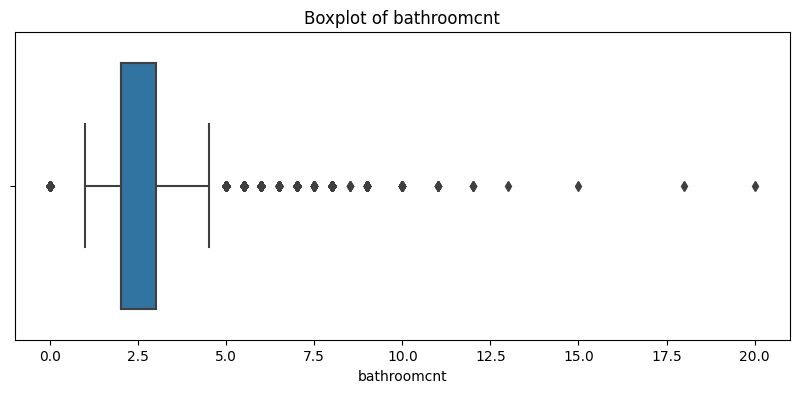

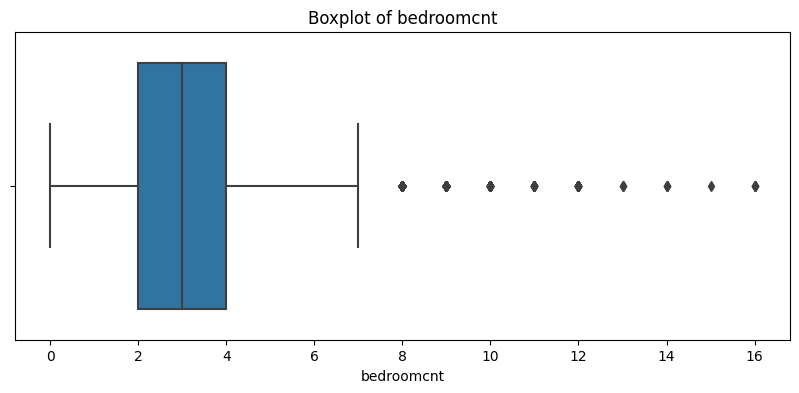

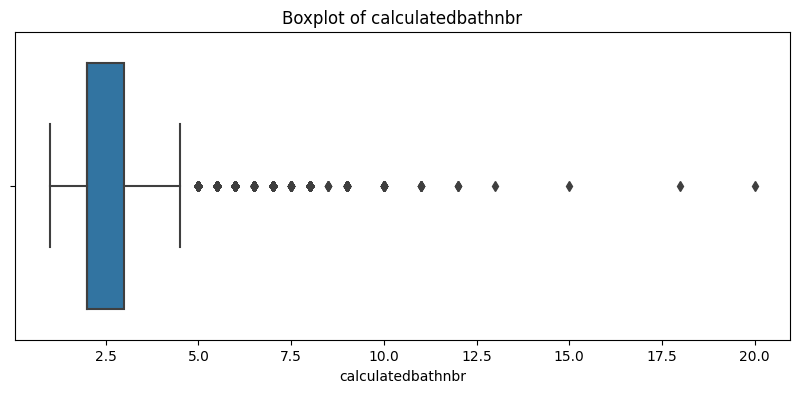

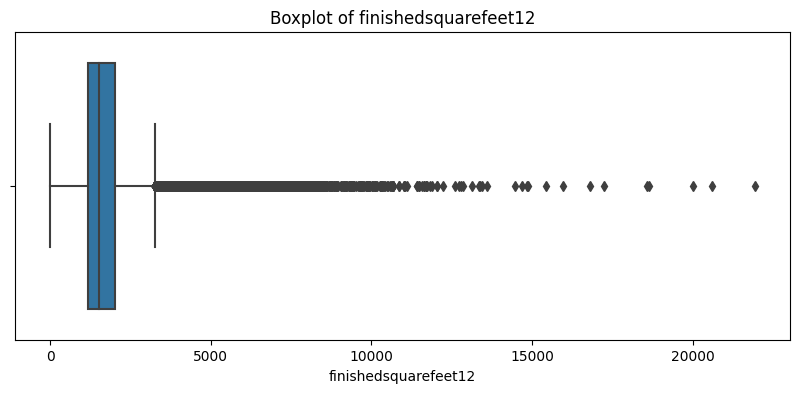

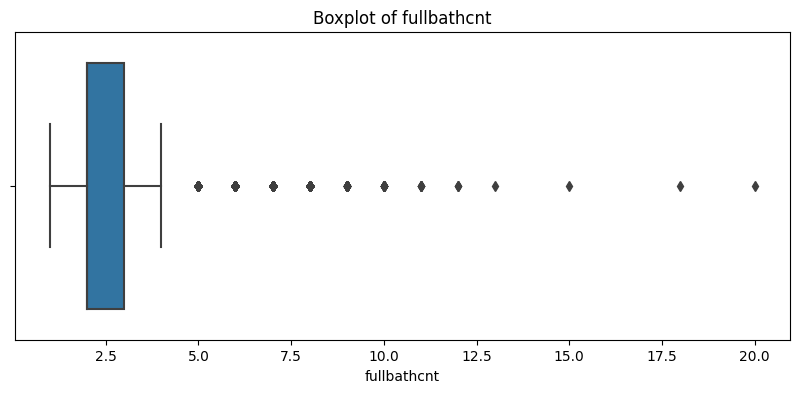

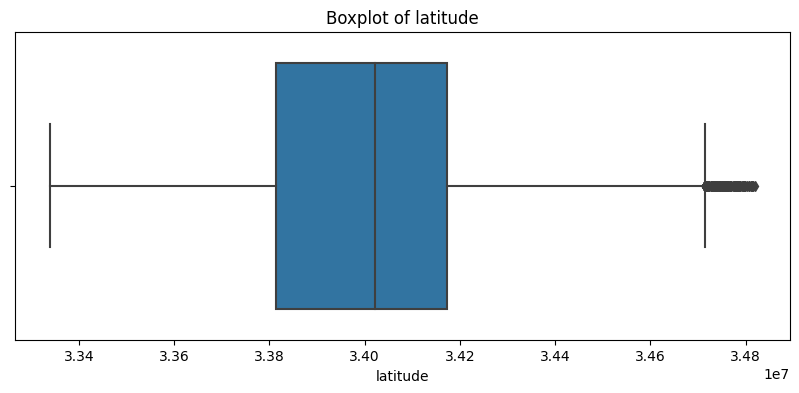

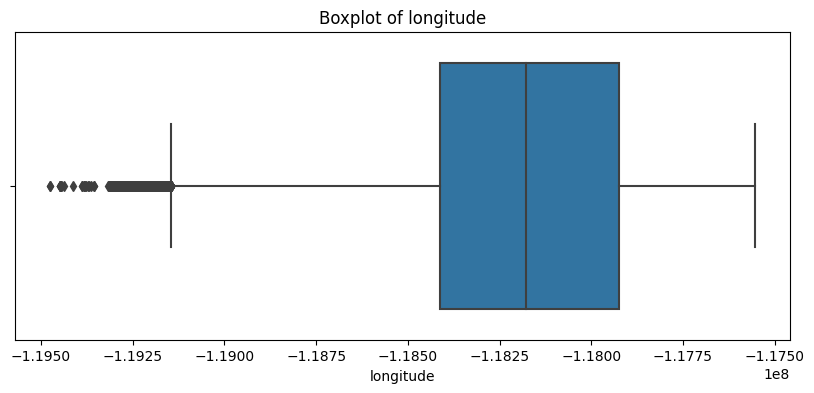

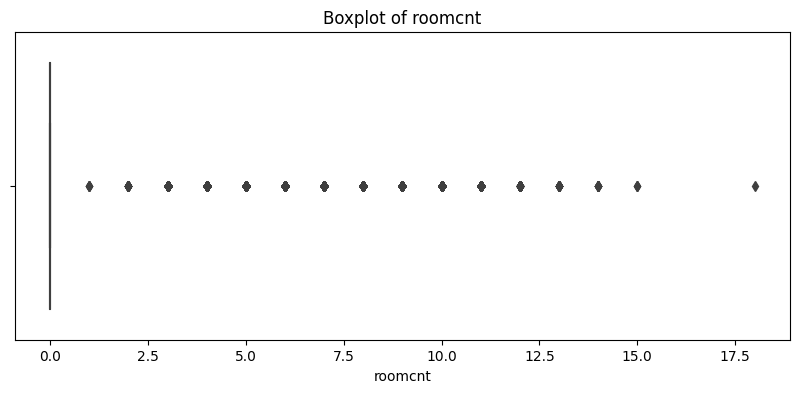

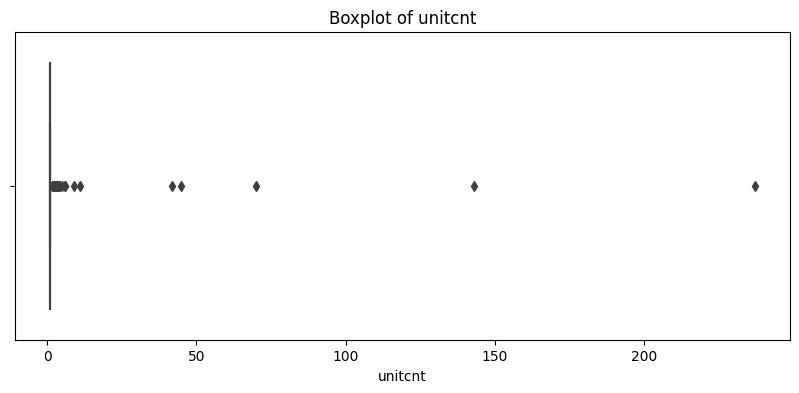

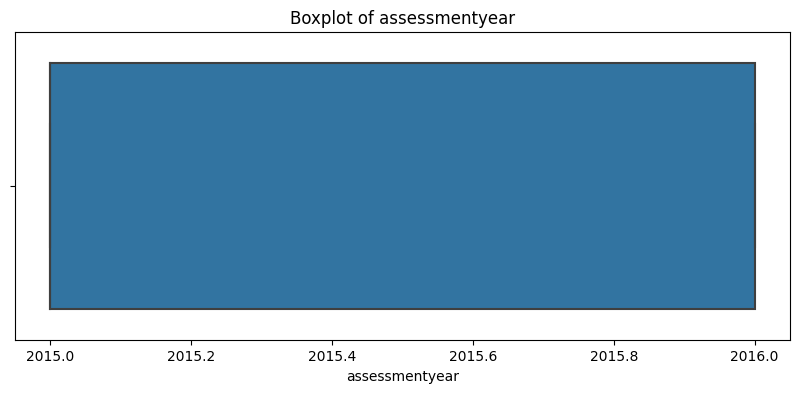

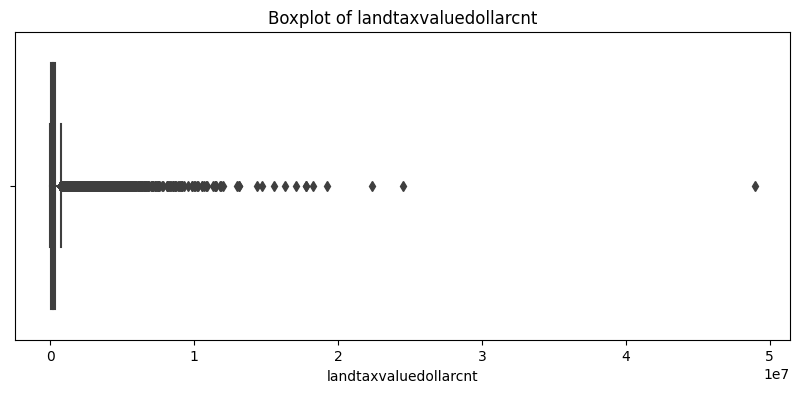

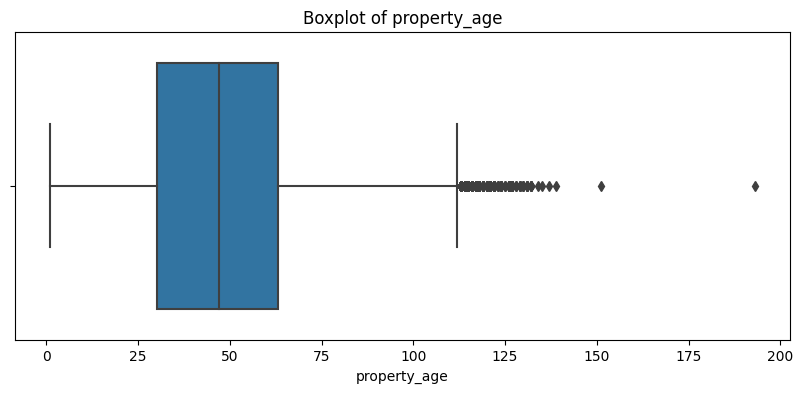

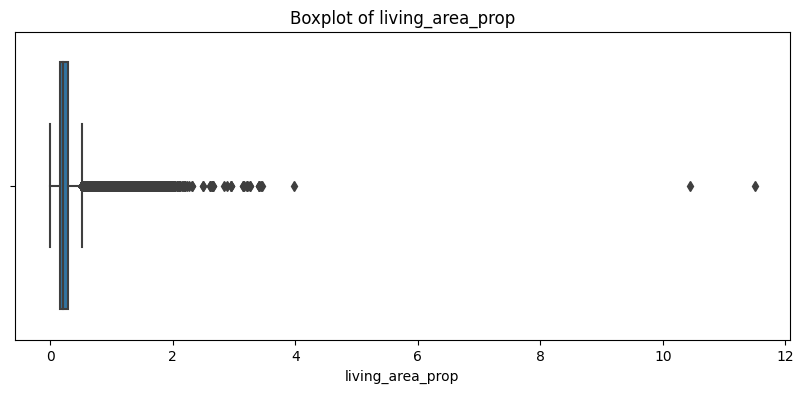

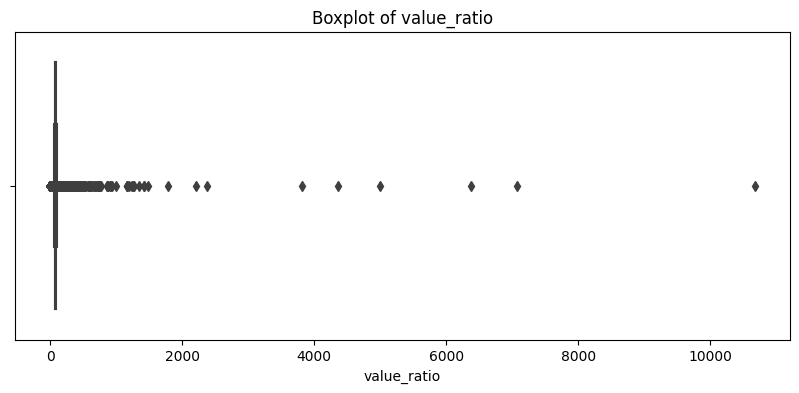

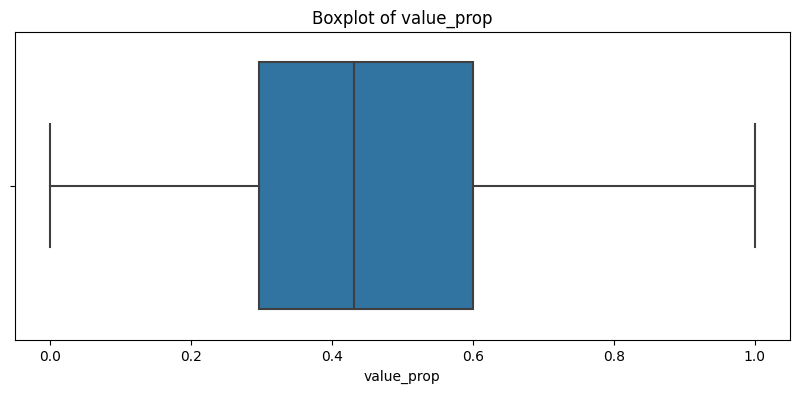

In [72]:
for col in numerical_cols:
    plt.figure(figsize=(10, 4)) 
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Lower Limit for:  bathroomcnt 0.5
Upper Limit for:  bathroomcnt 4.5


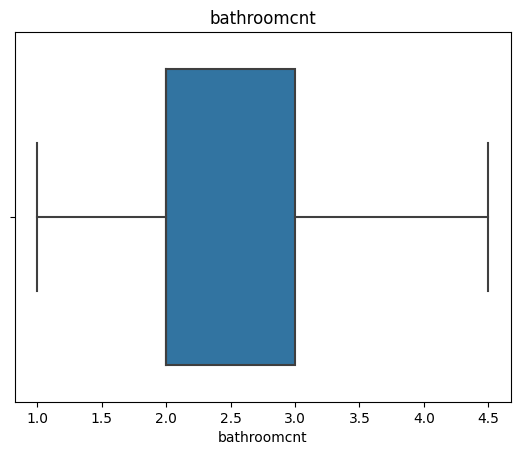

Lower Limit for:  bedroomcnt -1.0
Upper Limit for:  bedroomcnt 7.0


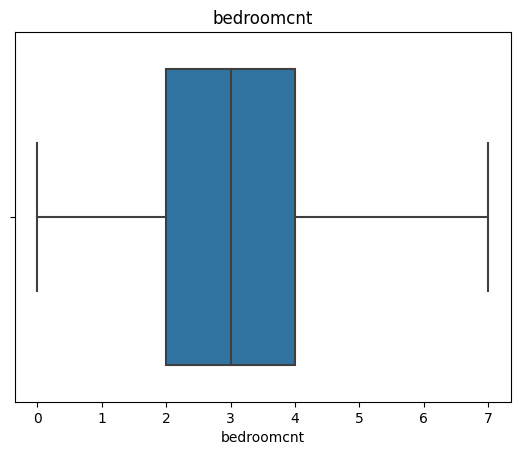

Lower Limit for:  calculatedbathnbr 0.5
Upper Limit for:  calculatedbathnbr 4.5


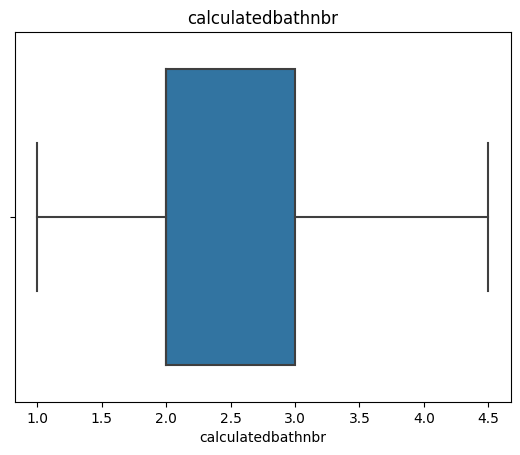

Lower Limit for:  finishedsquarefeet12 -59.5
Upper Limit for:  finishedsquarefeet12 3272.5


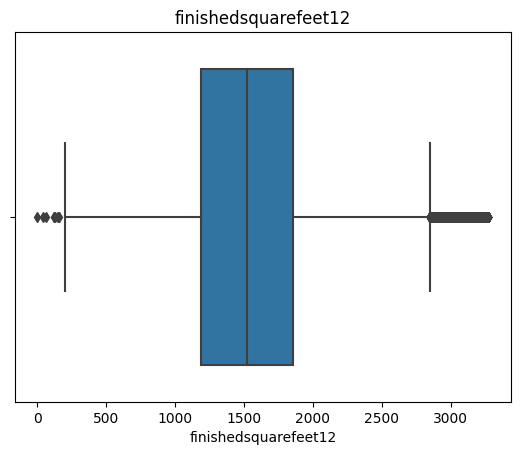

Lower Limit for:  fullbathcnt 0.5
Upper Limit for:  fullbathcnt 4.5


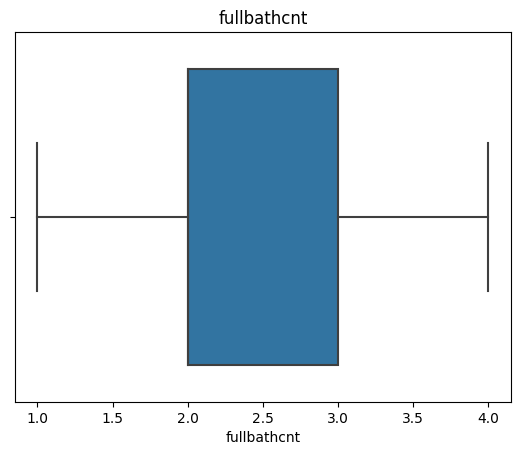

Lower Limit for:  latitude 33272293.75
Upper Limit for:  latitude 34714051.75


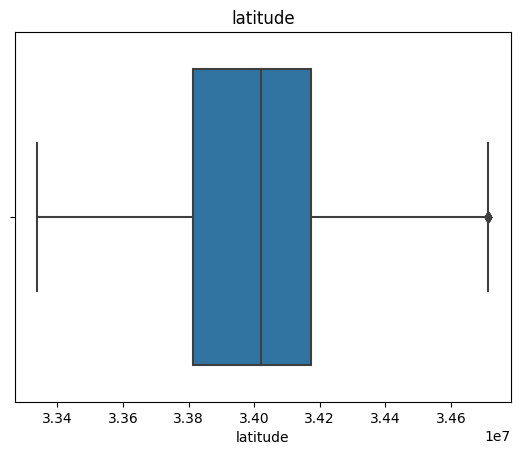

Lower Limit for:  longitude -119145381.75
Upper Limit for:  longitude -117192363.75


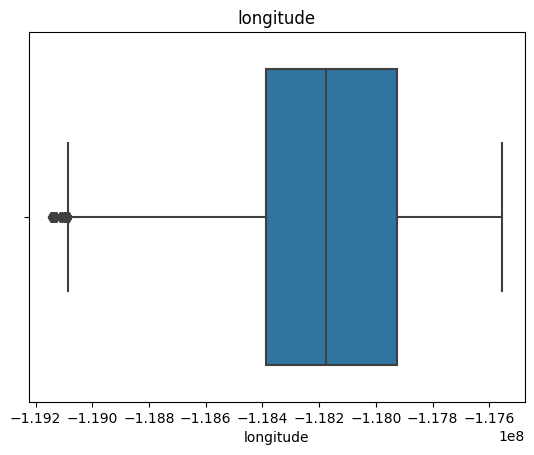

Lower Limit for:  roomcnt 0.0
Upper Limit for:  roomcnt 0.0


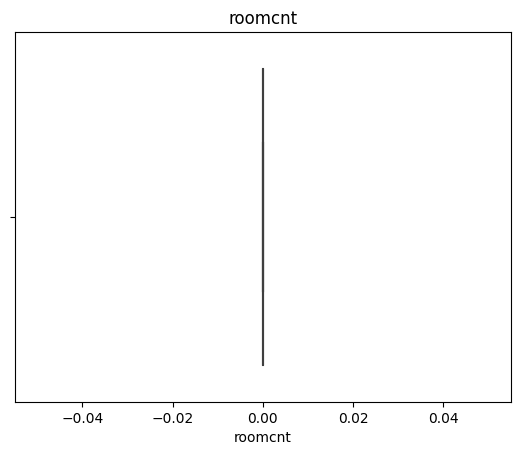

Lower Limit for:  unitcnt 1.0
Upper Limit for:  unitcnt 1.0


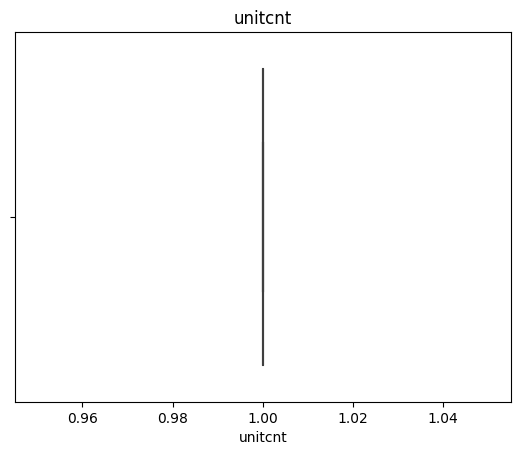

Lower Limit for:  assessmentyear 2013.5
Upper Limit for:  assessmentyear 2017.5


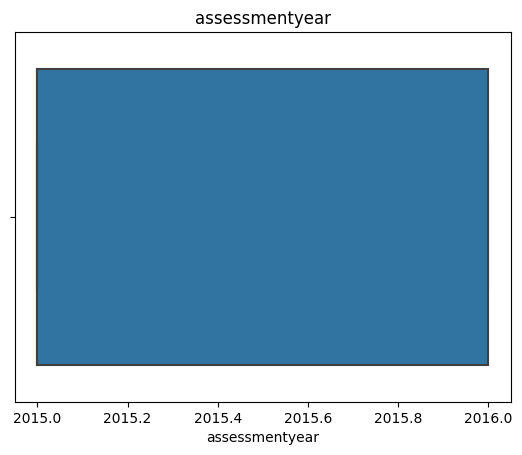

Lower Limit for:  landtaxvaluedollarcnt -323454.875
Upper Limit for:  landtaxvaluedollarcnt 762518.125


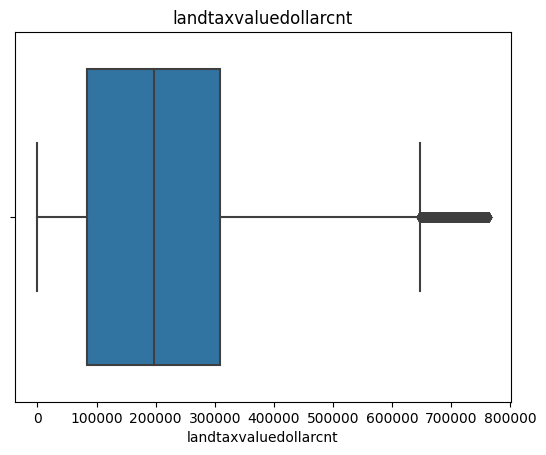

Lower Limit for:  property_age -19.5
Upper Limit for:  property_age 112.5


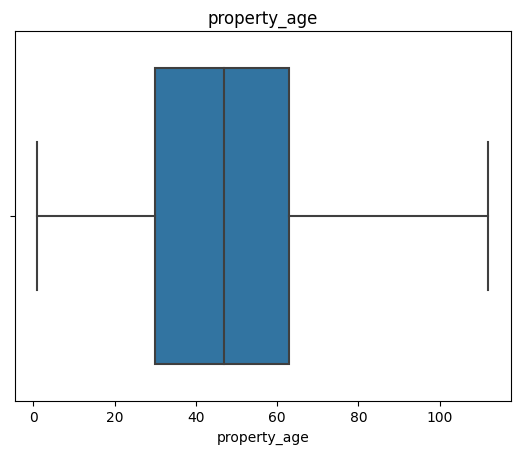

Lower Limit for:  living_area_prop -0.05774472957566737
Upper Limit for:  living_area_prop 0.5143420758406385


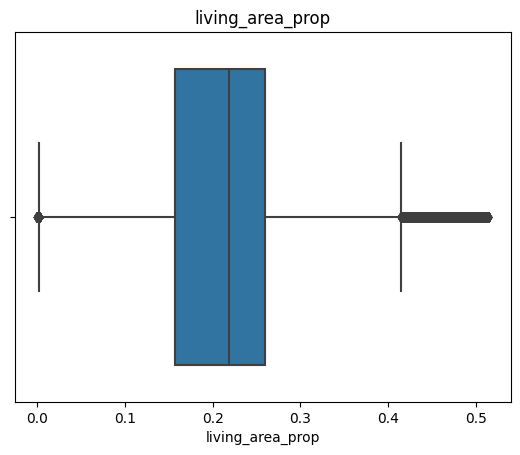

Lower Limit for:  value_ratio 52.87581714782598
Upper Limit for:  value_ratio 104.23043225134174


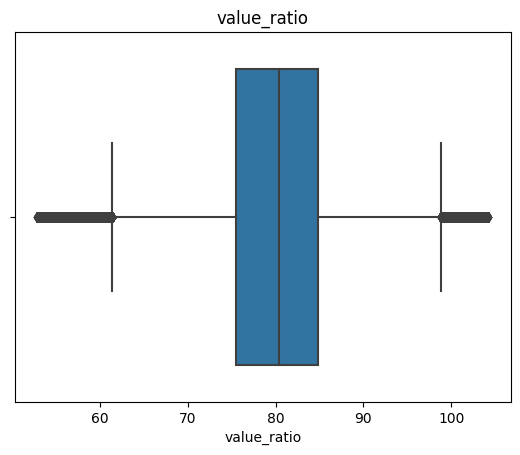

Lower Limit for:  value_prop -0.15827808498297208
Upper Limit for:  value_prop 1.0549767151374791


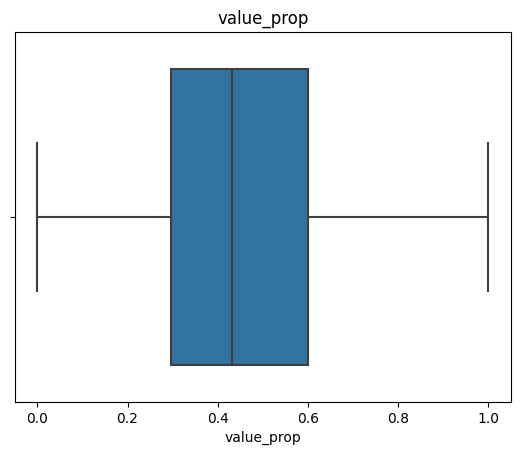

In [73]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print('Lower Limit for: ',col, lower) 
    print('Upper Limit for: ',col, upper)

    df.loc[df[col] > upper, col] = df[col].median()
    df.loc[df[col] < lower, col] = df[col].median()

    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


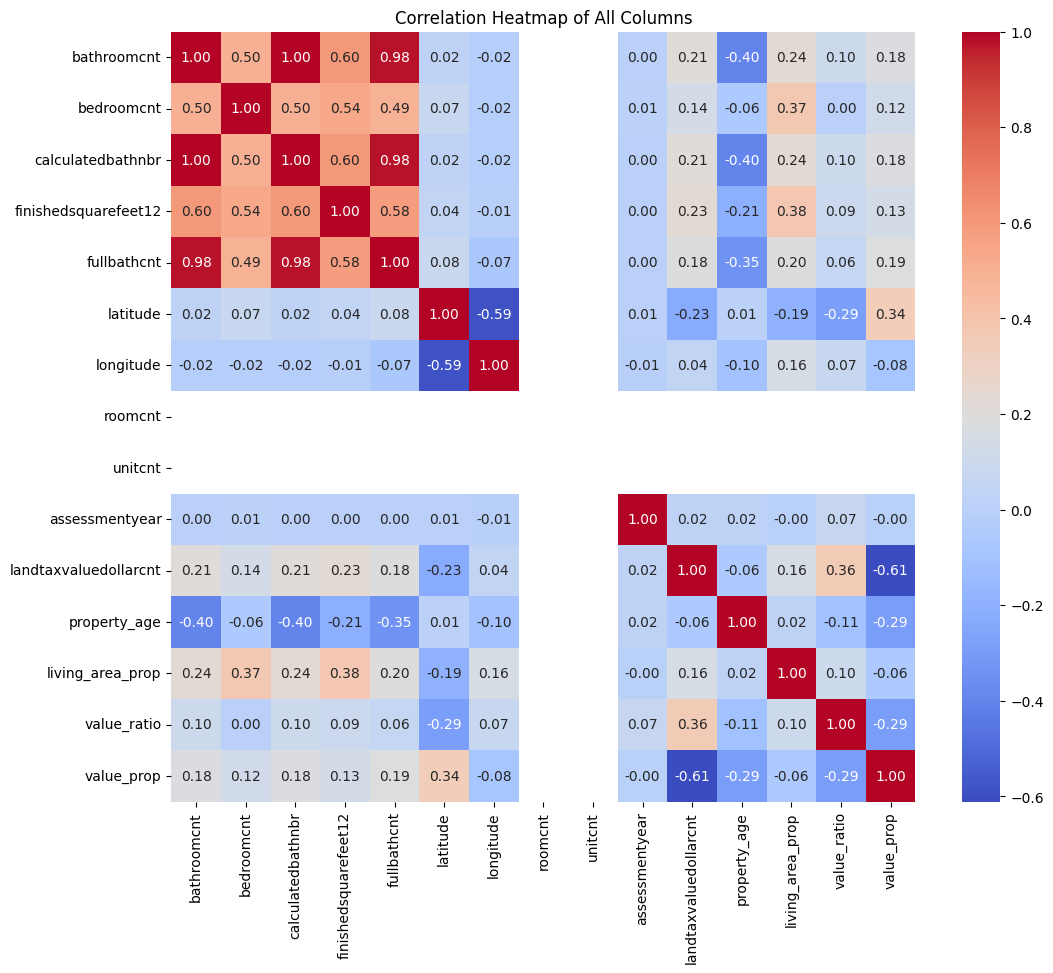

In [74]:
numerical_df = df[numerical_cols]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of All Columns')
plt.show()

In [75]:
for col in categorical_cols:
    df[col] = df[col].astype("category").cat.codes

In [76]:
df = df[(df['logerror'] > -0.4) & (df['logerror'] < 0.4)]

In [77]:
X = df.drop(columns=["logerror"])
y = df["logerror"].values

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train) 

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"Mean Absolute Error (MAE): {mae_lr}")
print(f"R-squared (R²) Score: {r2_lr}")

Mean Absolute Error (MAE): 0.05221092005756741
R-squared (R²) Score: 0.003860425609120921


In [80]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {"alpha": np.logspace(-4, 1, 20)}
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, ridge_params, scoring="neg_mean_absolute_error", cv=5)
ridge_cv.fit(X_train, y_train)
ridge_preds = ridge_cv.predict(X_test)

mae_r = mean_absolute_error(y_test, ridge_preds)
r2_r = r2_score(y_test, ridge_preds)
print(f"Mean Absolute Error (MAE): {mae_r}")
print(f"R-squared (R²) Score: {r2_r}")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.67713e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.67625e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.67914e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.67739e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarnin

Mean Absolute Error (MAE): 0.05220947380382949
R-squared (R²) Score: 0.0038969860664694878


In [81]:
from sklearn.linear_model import Lasso
lasso_params = {"alpha": np.logspace(-4, 1, 20)}
lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(lasso, lasso_params, scoring="neg_mean_absolute_error", cv=5)
lasso_cv.fit(X_train, y_train)
lasso_preds = lasso_cv.predict(X_test)

mae_lasso = mean_absolute_error(y_test, lasso_preds)
r2_lasso = r2_score(y_test, lasso_preds)

print(f"Mean Absolute Error (MAE): {mae_lasso}")
print(f"R-squared (R²) Score: {r2_lasso}")

Mean Absolute Error (MAE): 0.05220274958767219
R-squared (R²) Score: 0.0030093055094992938


In [82]:
sub = pd.read_csv('/kaggle/input/zillow-prize-1/sample_submission.csv')
sub

,ParcelId,201610,201611,201612,201710,201711,201712
0,10754147,0,0,0,0,0,0
1,10759547,0,0,0,0,0,0
2,10843547,0,0,0,0,0,0
3,10859147,0,0,0,0,0,0
4,10879947,0,0,0,0,0,0
...,...,...,...,...,...,...,...
2985212,168176230,0,0,0,0,0,0
2985213,14273630,0,0,0,0,0,0
2985214,168040630,0,0,0,0,0,0
2985215,168040830,0,0,0,0,0,0


In [83]:
X_final= pd.concat([properties_2016, properties_2017], ignore_index=True).drop_duplicates(subset='parcelid', keep='last')

In [86]:
test_df = pd.merge(sub[['ParcelId']], X_final, left_on='ParcelId', right_on='parcelid', how='left')
test_df.drop('ParcelId', axis=1, inplace=True)

In [87]:
test_df=test_df.drop(columns=['airconditioningtypeid','architecturalstyletypeid','basementsqft','buildingclasstypeid','decktypeid','finishedfloor1squarefeet','finishedsquarefeet13','finishedsquarefeet15','finishedsquarefeet50','finishedsquarefeet6','fireplacecnt','garagecarcnt','garagetotalsqft','hashottuborspa','poolcnt','poolsizesum','pooltypeid10','pooltypeid2','pooltypeid7','regionidneighborhood','storytypeid','threequarterbathnbr','typeconstructiontypeid','yardbuildingsqft17','yardbuildingsqft26','numberofstories','fireplaceflag','taxdelinquencyflag','taxdelinquencyyear'])

In [ ]:
test_df['transaction_month'] = 11 
test_df['property_age'] = 2017 - test_df['yearbuilt']

test_df['living_area_prop'] = test_df['calculatedfinishedsquarefeet'] / test_df['lotsizesquarefeet']

test_df['value_ratio'] = test_df['taxvaluedollarcnt'] /test_df['taxamount']

test_df['value_prop'] = test_df['structuretaxvaluedollarcnt'] / test_df['taxvaluedollarcnt']
test_df.head()

In [ ]:
test_df=test_df.drop(columns=['yearbuilt','calculatedfinishedsquarefeet','lotsizesquarefeet','taxvaluedollarcnt','taxamount','structuretaxvaluedollarcnt'])

In [ ]:
for col in numerical_cols:
    if col in test_df.columns:
        test_df[col].fillna(X_train[col].median(), inplace=True)

for col in categorical_cols:
    if col in test_df.columns:
        test_df[col].fillna(X_train[col].mode()[0], inplace=True)

In [ ]:
best_model = lasso_cv 

for col in categorical_cols:
    test_df[col] = test_df[col].astype("category").cat.codes

In [ ]:
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

In [ ]:
test_df_for_prediction = test_df.drop(columns=['parcelid'], errors='ignore')

In [ ]:
predictions = best_model.predict(test_df_for_prediction)

In [ ]:
print(test_df.columns.tolist())

In [ ]:
submission_df = pd.DataFrame()
submission_df['ParcelId'] = test_df['parcelid']

submission_df['201610'] = predictions
submission_df['201611'] = predictions
submission_df['201612'] = predictions
submission_df['201710'] = predictions
submission_df['201711'] = predictions
submission_df['201712'] = predictions

In [ ]:
submission_df.to_csv('submission.csv', index=False)